# ✅ What is Gradient Descent?
* Gradient Descent is an algorithm that updates model parameters (like weights in linear regression) to reduce the error.
* The idea:
* Start with random values (weights)
* Calculate error (loss)
* Find the gradient (slope)
* Move in the opposite direction of the gradient
* Repeat until the model finds the minimum error

# 📉 Why “descent”?
* Because the algorithm always moves downhill on the loss function curve — towards the minimum.

# 📌 Learning Rate (α)
* Very important parameter!
* If α is too small → training becomes very slow
* If α is too big → model overshoots and never converges
 * Good α values: 0.001, 0.01, 0.1

# 🔁 Types of Gradient Descent
* 1. Batch Gradient Descent
* Uses entire dataset
* ✔ More stable
* ✘ Slow for large data


# 2. Stochastic Gradient Descent (SGD)
* Uses one data point per update
* ✔ Fast
* ✘ Noisy updates

# 3. Mini-Batch Gradient Descent
* Uses small batches (32, 64, 128)
* ✔ Fast + Stable
* ✔ Most used in Deep Learning

# 🎯 Intuition Simple Example
Imagine you are at the top of a mountain in the dark.
You want to reach the bottom.
You take small steps based on the slope → this is gradient descent.

In [1]:
from sklearn.datasets import make_regression
import numpy as np

In [3]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)

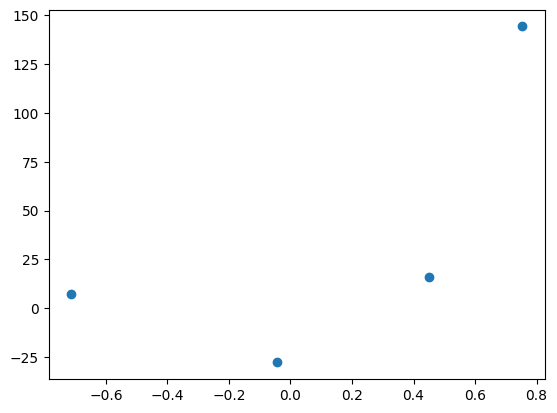

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [5]:
# Lets apply OLS
from sklearn.linear_model import LinearRegression

In [7]:
reg = LinearRegression()
reg.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
reg.coef_

array([78.35063668])

In [20]:
reg.intercept_

np.float64(26.15963284313262)

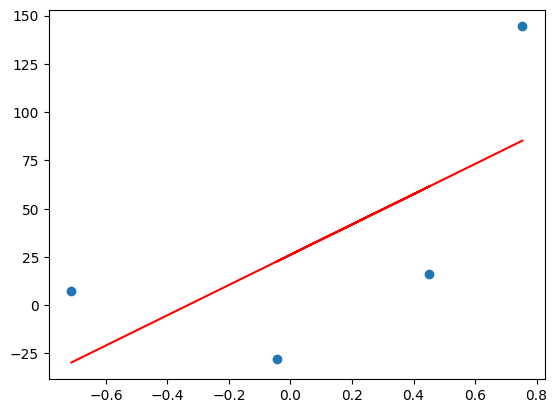

In [26]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X), color = 'red' )

In [24]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred = ((78.35 * X) + 100).reshape(4)

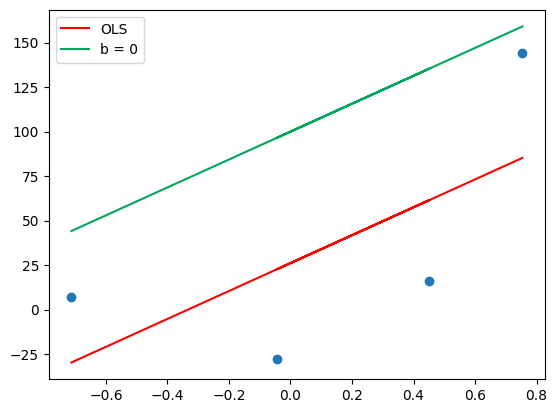

In [25]:

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show()

In [27]:
m = 78.35
b = 100

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope
     

np.float64(590.7223659179078)

In [30]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size
     

np.float64(59.072236591790784)

In [31]:

# Calculating the new intercept
b = b - step_size
b

np.float64(40.927763408209216)

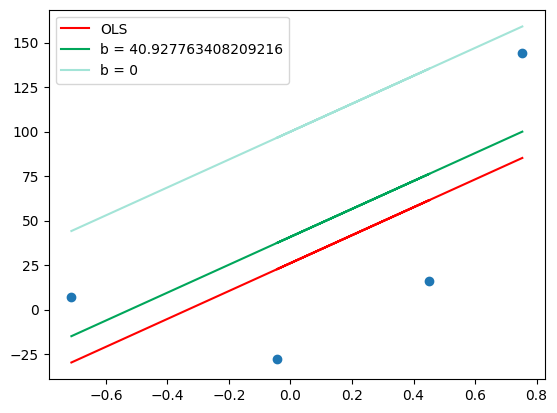

In [32]:

y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [33]:

# Iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope
     

np.float64(118.14447318358157)

In [34]:

step_size = loss_slope*lr
step_size
     

np.float64(11.814447318358157)

In [35]:

b = b - step_size
b

np.float64(29.11331608985106)

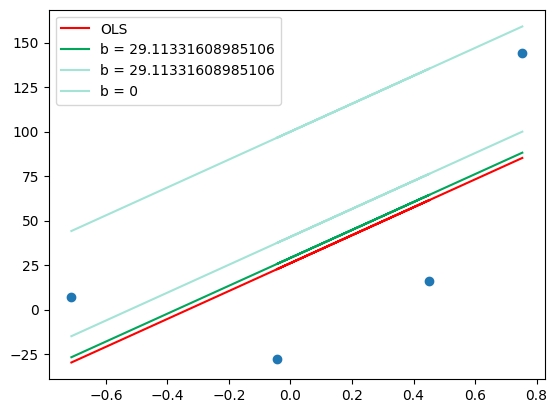

In [36]:

y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()
     

In [37]:

# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(23.62889463671631)

In [39]:

step_size = loss_slope*lr
step_size

np.float64(2.3628894636716313)

In [40]:
b = b - step_size
b

np.float64(26.75042662617943)

In [41]:
y_pred3 = ((78.35 * X) + b).reshape(4)

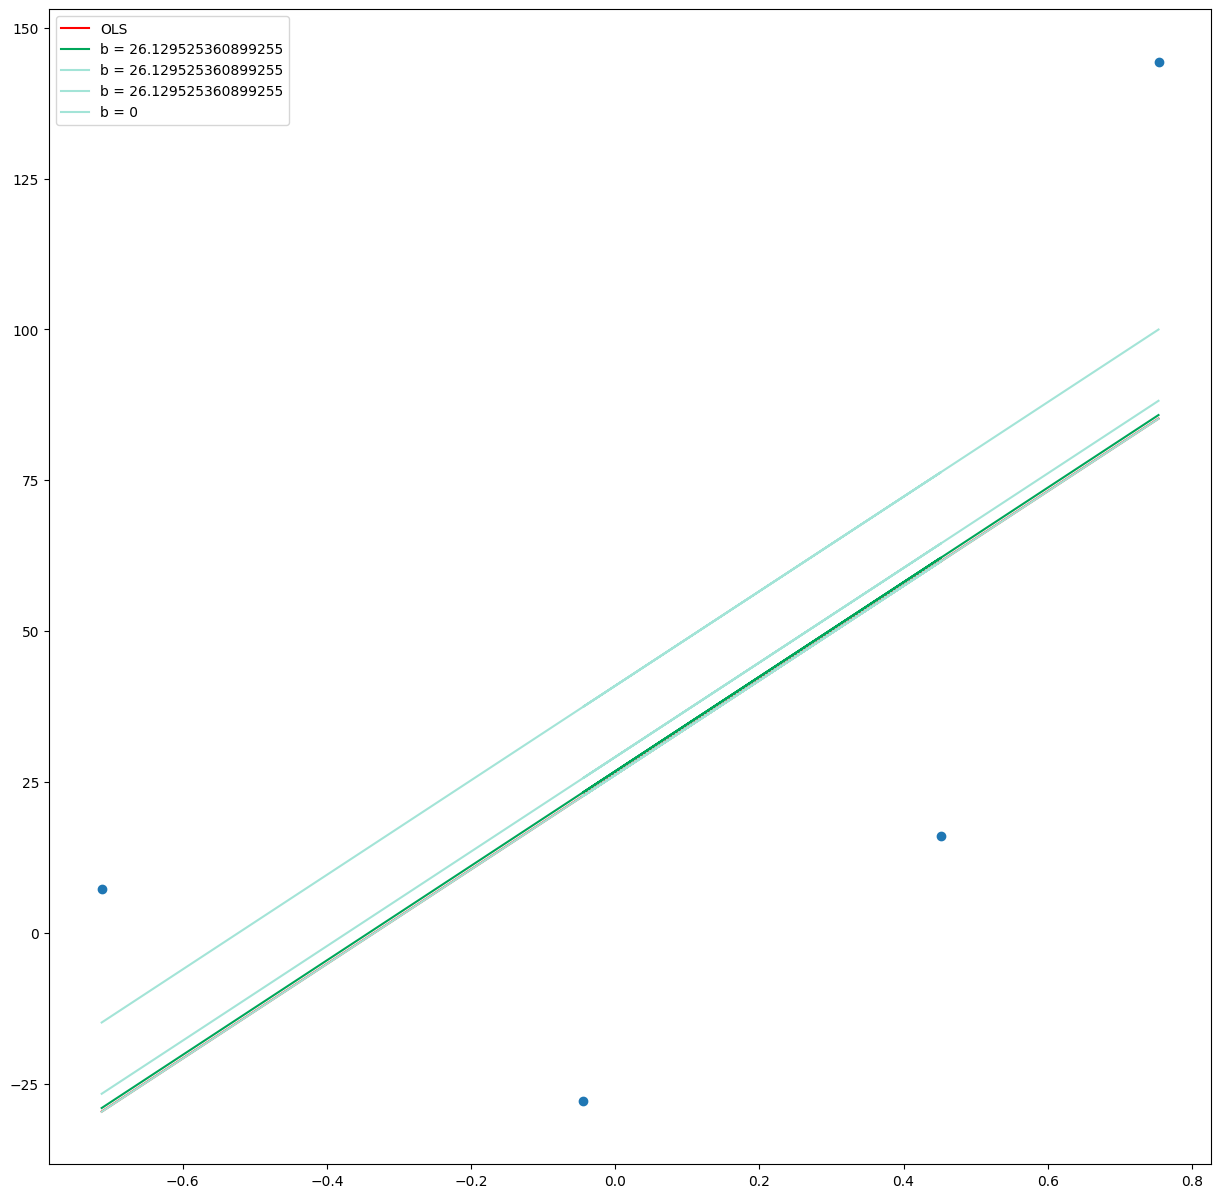

In [45]:
plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
# plt.tight_layout()
plt.show()

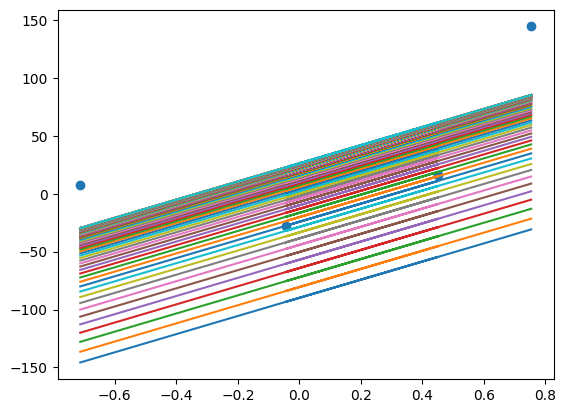

In [43]:
b = -100
m = 78.35
lr = 0.01

epochs = 100

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * X + b

  plt.plot(X,y_pred)

plt.scatter(X,y)